# Extended Figure 8. Mural cell states at single-nucleus and spatial resolution

2 panels of this figure are built below, one section each.

---

## Setup

In [1]:
%matplotlib inline
%config InlineBackend.figure_formats = ['retina']
import sys
sys.path[:0] = ["../src", "../figures/_lib", "../figures/ED8"]
from hhca.paths import TABLES, OUT
print('inputs :', TABLES)
print('outputs:', OUT)

inputs : /Volumes/Storage/hhca_spatial_tables
outputs: /Users/maiia.shulman/hhca_release_out


## ED8 b

ED 8b — atrial-pericyte signature genes (29 in Visium) x chamber: mean z-scored expression over all

Input:
- `heart_results/atrial_pericyte_ED8c/ED8c_gene_by_chamber_z.csv`

Source: `figures/ED8/panel_b.py`

saved ED8 b | 29 genes, vmax=0.410


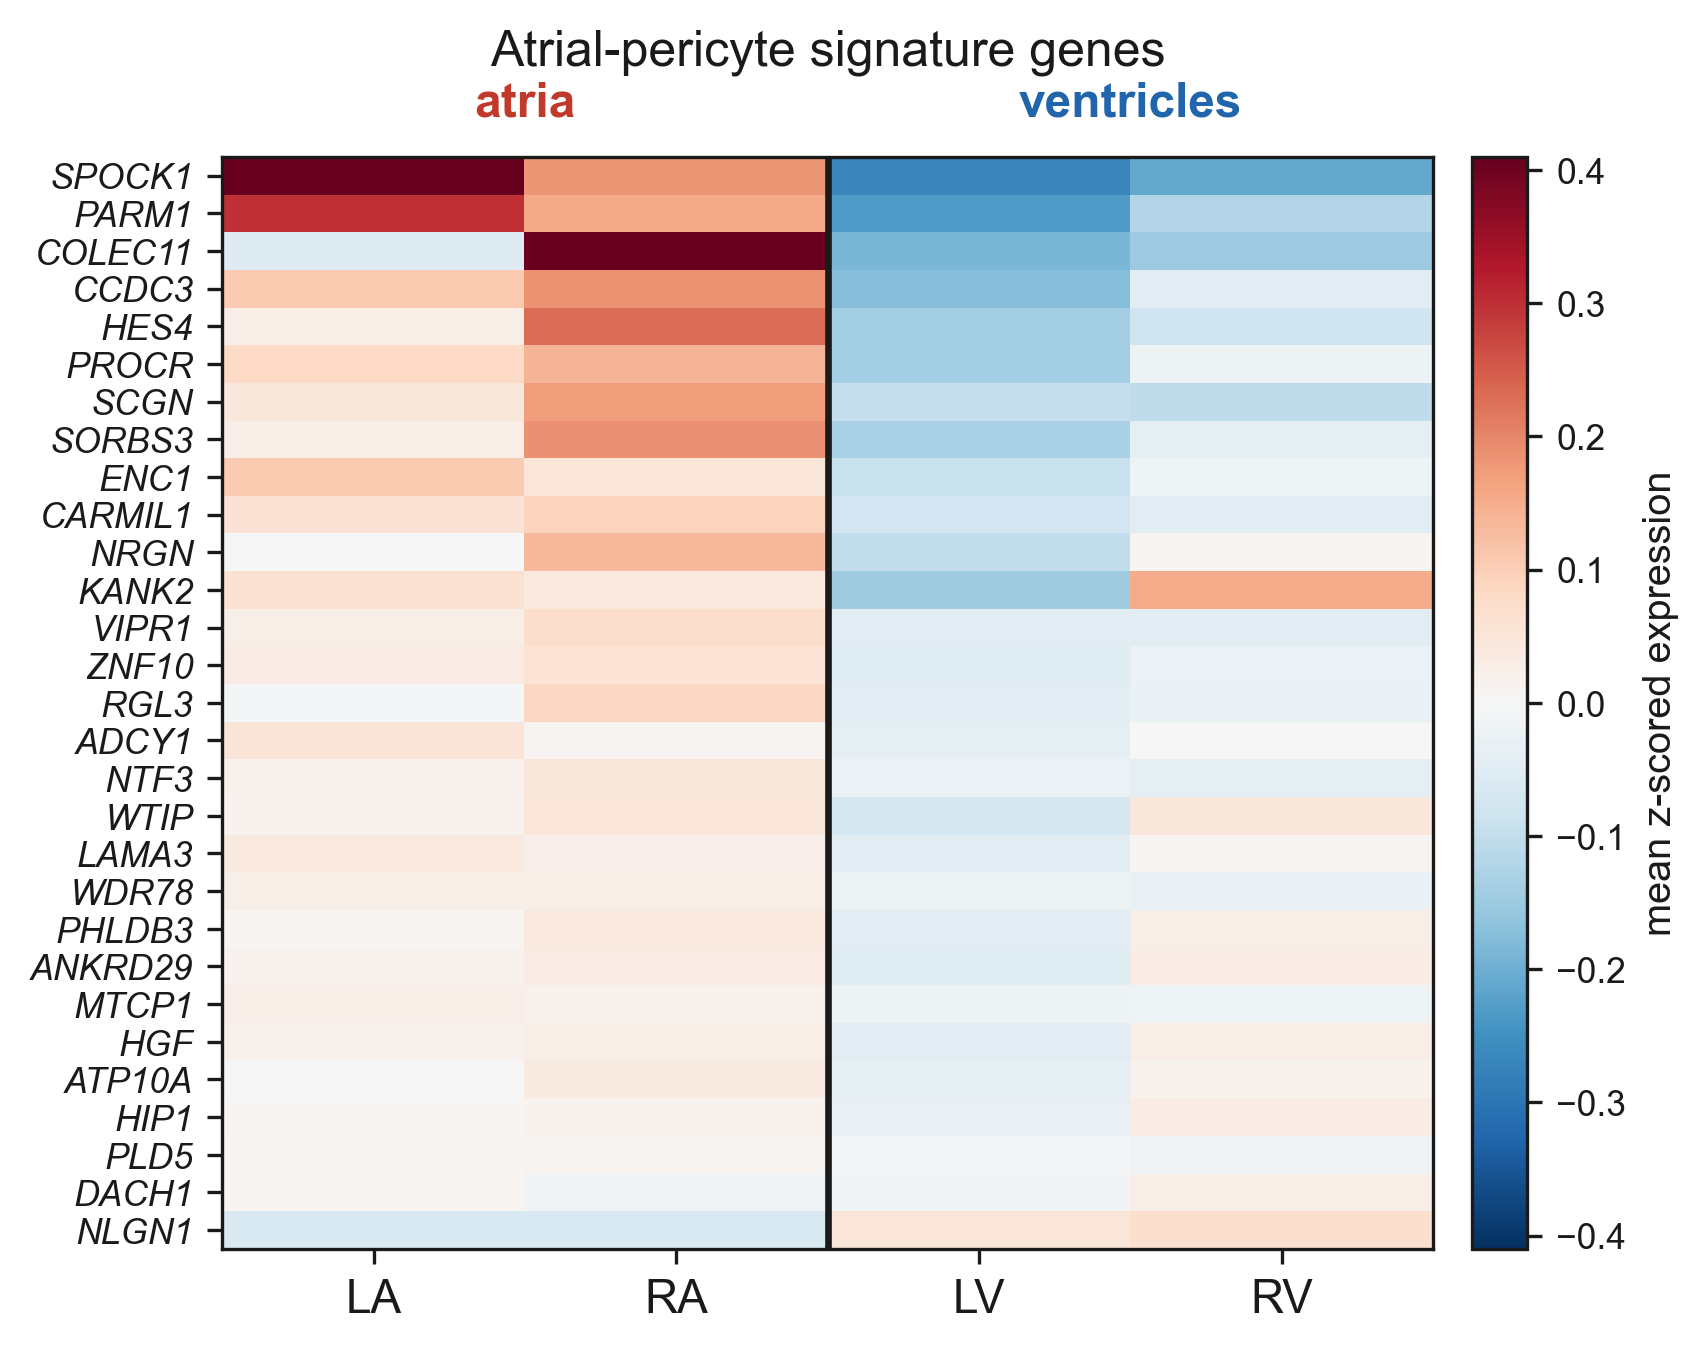

In [2]:
from hhca.paths import TABLES
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from pubfig import save

ED8C = f"{TABLES}/heart_results/atrial_pericyte_ED8c"
INK, MUTED = "#1a1a1a", "#6E6E6E"
COL = {"atria": "#C0392B", "ventricle": "#2166AC"}
mpl.rcParams.update({"pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
                     "font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
                     "axes.labelcolor": INK, "text.color": INK, "xtick.color": INK, "ytick.color": INK,
                     "axes.edgecolor": INK, "figure.dpi": 150})

M = pd.read_csv(f"{ED8C}/ED8c_gene_by_chamber_z.csv", index_col=0)

fig = plt.figure(figsize=(15.4, 5.2))
gs = fig.add_gridspec(1, 3, width_ratios=[1.35, 1, 1], wspace=.42, left=.075, right=.975, top=.86, bottom=.16)
ax = fig.add_subplot(gs[0])
vm = float(np.nanmax(np.abs(M.values)))
im = ax.imshow(M.values, cmap="RdBu_r", vmin=-vm, vmax=vm, aspect="auto")
ax.set_xticks(range(4))
ax.set_xticklabels(["LA", "RA", "LV", "RV"], fontsize=11)
ax.set_yticks(range(len(M)))
ax.set_yticklabels(M.index, fontsize=8.5, style="italic")
ax.axvline(1.5, color=INK, lw=1.6)
ax.text(0.5, -1.6, "atria", ha="center", fontsize=11.5, color=COL["atria"], fontweight="bold")
ax.text(2.5, -1.6, "ventricles", ha="center", fontsize=11.5, color=COL["ventricle"], fontweight="bold")
cb = fig.colorbar(im, ax=ax, fraction=.045, pad=.03)
cb.set_label("mean z-scored expression", fontsize=9.5)
cb.ax.tick_params(labelsize=8.5)
ax.set_title("Atrial-pericyte signature genes", fontsize=12, pad=22)
save(fig, "ED8", "b", bbox_inches="tight")
print(f"saved ED8 b | {M.shape[0]} genes, vmax={vm:.3f}")


## ED8 c

ED 8c — atrial-pericyte signature score in pericyte-high Kanemaru Visium spots (top within-region tertile

Input:
- `heart_results/atrial_pericyte_ED8c/ED8c_perspot.csv.gz`

Source: `figures/ED8/panel_c.py`

saved ED8 c | n=4889 vs 4283, median -0.078 vs 0.070, p=2.8e-265


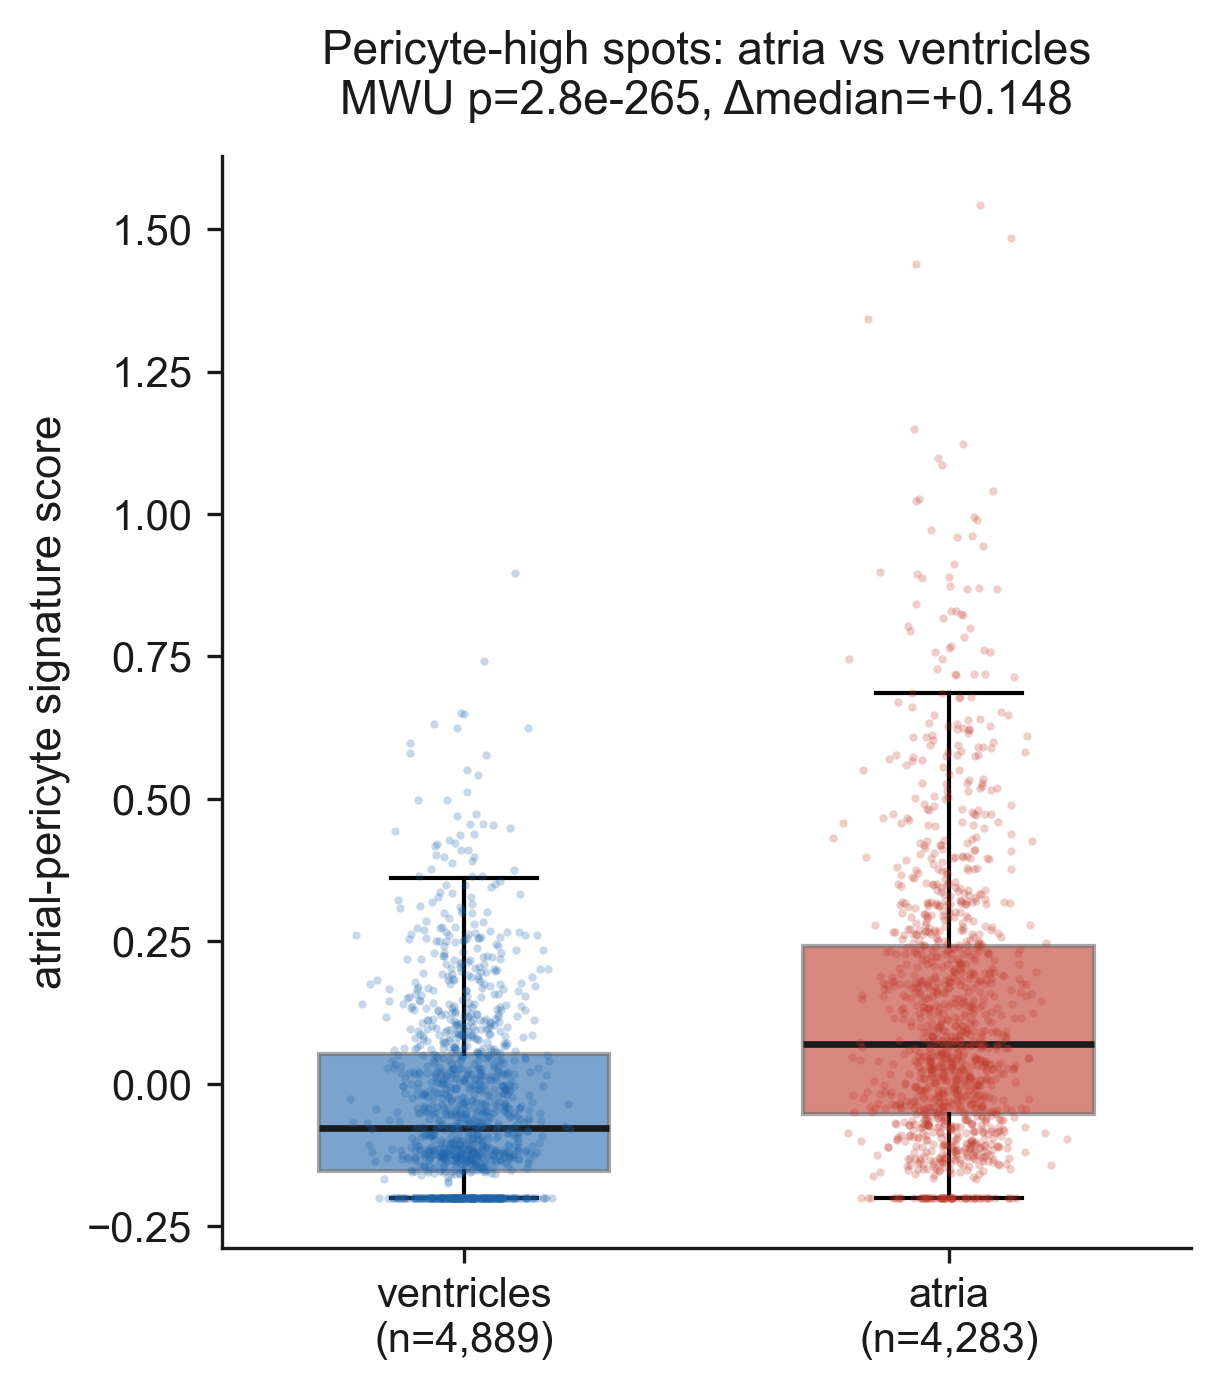

In [3]:
from hhca.paths import TABLES
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt
from pubfig import save

ED8C = f"{TABLES}/heart_results/atrial_pericyte_ED8c"
INK, MUTED = "#1a1a1a", "#6E6E6E"
COL = {"atria": "#C0392B", "ventricle": "#2166AC"}
mpl.rcParams.update({"pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
                     "font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
                     "axes.labelcolor": INK, "text.color": INK, "xtick.color": INK, "ytick.color": INK,
                     "axes.edgecolor": INK, "figure.dpi": 150})

D = pd.read_csv(f"{ED8C}/ED8c_perspot.csv.gz", index_col=0)

# replay panel (b)'s random draws (atria, pericyte-low then pericyte-high) so panel (c) gets the same stream
rng = np.random.default_rng(0)
at = D[D.region == "atria"]
for i, g in enumerate(["pericyte-low", "pericyte-high"]):
    v = at[at.peri_grp == g].score.values
    s = v if len(v) <= 1200 else rng.choice(v, 1200, replace=False)
    rng.normal(i, .07, len(s))

fig = plt.figure(figsize=(15.4, 5.2))
gs = fig.add_gridspec(1, 3, width_ratios=[1.35, 1, 1], wspace=.42, left=.075, right=.975, top=.86, bottom=.16)
ax = fig.add_subplot(gs[2])
hi = D[D.peri_grp == "pericyte-high"]
vals = [hi[hi.region == r].score.values for r in ["ventricle", "atria"]]
u2 = stats.mannwhitneyu(vals[1], vals[0], alternative="two-sided")
bp = ax.boxplot(vals, positions=[0, 1], widths=.6, patch_artist=True, showfliers=False,
                medianprops=dict(color=INK, lw=1.6))
for p_, c_ in zip(bp["boxes"], [COL["ventricle"], COL["atria"]]):
    p_.set_facecolor(c_)
    p_.set_alpha(.6)
    p_.set_edgecolor(MUTED)
for i, v in enumerate(vals):
    s = v if len(v) <= 1200 else rng.choice(v, 1200, replace=False)
    ax.scatter(rng.normal(i, .07, len(s)), s, s=4, alpha=.25, lw=0, color=[COL["ventricle"], COL["atria"]][i],
               zorder=3)
ax.set_xticks([0, 1])
ax.set_xticklabels([f"ventricles\n(n={len(vals[0]):,})", f"atria\n(n={len(vals[1]):,})"], fontsize=10)
ax.set_ylabel("atrial-pericyte signature score", fontsize=10.5)
ax.set_title(f"Pericyte-high spots: atria vs ventricles\nMWU p={u2.pvalue:.2g}, "
             f"Δmedian={np.median(vals[1]) - np.median(vals[0]):+.3f}", fontsize=11, pad=10)
for s_ in ("top", "right"):
    ax.spines[s_].set_visible(False)
save(fig, "ED8", "c", bbox_inches="tight")
print(f"saved ED8 c | n={len(vals[0])} vs {len(vals[1])}, median {np.median(vals[0]):.3f} vs "
      f"{np.median(vals[1]):.3f}, p={u2.pvalue:.3g}")
